# ============================================================
# 02 · MODELADO — Random Forest
# ============================================================
# Objetivo: Entrenar y evaluar Random Forest como modelo 
# principal para predecir qué clientes tienen mayor 
# probabilidad de suscribir un depósito a plazo fijo.
# ============================================================

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

print("Librerías importadas")



Librerías importadas


In [18]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\nBalance en train:\n{y_train.value_counts()}")
print(f"\nBalance en test:\n{y_test.value_counts()}")

X_train: (63874, 51) | y_train: (63874,)
X_test:  (9043, 51)  | y_test:  (9043,)

Balance en train:
y
0    31937
1    31937
Name: count, dtype: int64

Balance en test:
y
0    7985
1    1058
Name: count, dtype: int64


# ============================================================
# ⚠️ MÉTRICA CORRECTA PARA DATOS DESBALANCEADOS
# ============================================================
# Con un 88% de clase "no", un modelo que prediga siempre "no"
# tendría un 88% de accuracy → parece bueno pero es inútil.
#
# Métricas que usaremos:
#   - F1-Score:  equilibrio entre Precision y Recall
#   - AUC-ROC:   capacidad de separar las dos clases
#   - Recall:    de todos los que SÍ suscriben, ¿cuántos detectamos?
#                → minimizar falsos negativos es nuestro objetivo
# ============================================================

In [19]:
print("✅ Métrica principal: F1-Score + AUC-ROC")
print("✅ Objetivo de negocio: maximizar Recall en clase yes")

✅ Métrica principal: F1-Score + AUC-ROC
✅ Objetivo de negocio: maximizar Recall en clase yes


# Función de evaluación reutilizable

In [20]:
def evaluar_modelo(modelo, X_test, y_test, nombre="Modelo"):
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*55}")
    print(f"  EVALUACIÓN: {nombre}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, 
                                 target_names=['No suscribe', 'Suscribe']))
    
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    
    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No suscribe', 'Suscribe'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'Matriz de Confusión — {nombre}')
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='#2ecc71', lw=2,
                 label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1], [0,1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC — {nombre}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {'nombre': nombre, 'auc': auc, 'f1': f1,
            'y_pred': y_pred, 'y_proba': y_proba}

⏳ Entrenando Random Forest baseline...
✅ Random Forest baseline entrenado

  EVALUACIÓN: Random Forest Baseline
              precision    recall  f1-score   support

 No suscribe       0.91      0.96      0.94      7985
    Suscribe       0.51      0.32      0.39      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.64      0.66      9043
weighted avg       0.87      0.88      0.87      9043

  AUC-ROC : 0.7827
  F1-Score: 0.3907


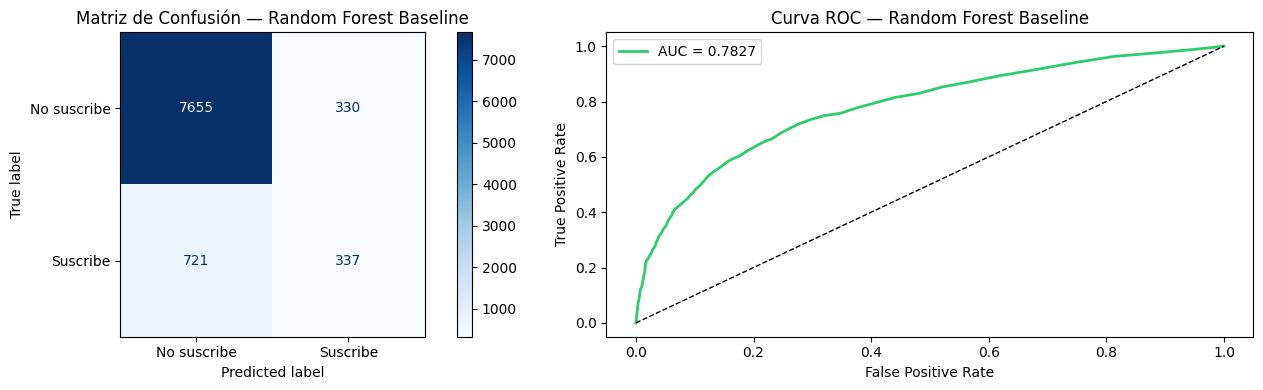

In [21]:
print("⏳ Entrenando Random Forest baseline...")

rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)
print("✅ Random Forest baseline entrenado")

resultados_base = evaluar_modelo(rf_base, X_test, y_test, 
                                  "Random Forest Baseline")

In [22]:
print("⏳ Buscando mejores hiperparámetros...")
print("   Esto puede tardar 10-15 minutos, es normal.\n")

param_grid = {
    'n_estimators'      : [100, 200],
    'max_depth'         : [10, 20, None],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(
                     class_weight='balanced',
                     random_state=42,
                     n_jobs=-1),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor F1 en validación cruzada: {grid_search.best_score_:.4f}")

⏳ Buscando mejores hiperparámetros...
   Esto puede tardar 10-15 minutos, es normal.

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Mejores hiperparámetros encontrados:
{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}

Mejor F1 en validación cruzada: 0.9310



  EVALUACIÓN: Random Forest Optimizado
              precision    recall  f1-score   support

 No suscribe       0.91      0.96      0.94      7985
    Suscribe       0.50      0.31      0.39      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.64      0.66      9043
weighted avg       0.86      0.88      0.87      9043

  AUC-ROC : 0.7823
  F1-Score: 0.3856


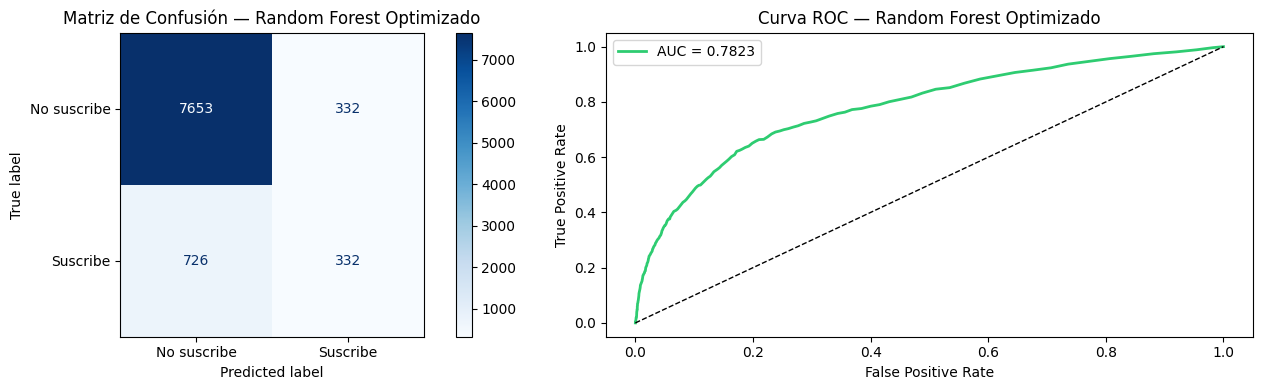


📊 BASELINE vs OPTIMIZADO
Modelo                             F1    AUC
---------------------------------------------
RF Baseline                    0.3907 0.7827
RF Optimizado                  0.3856 0.7823


In [23]:
rf_optimizado = grid_search.best_estimator_

resultados_rf = evaluar_modelo(rf_optimizado, X_test, y_test,
                                "Random Forest Optimizado")

# Comparar baseline vs optimizado
print("\n📊 BASELINE vs OPTIMIZADO")
print("="*45)
print(f"{'Modelo':<30} {'F1':>6} {'AUC':>6}")
print("-"*45)
print(f"{'RF Baseline':<30} {resultados_base['f1']:>6.4f} {resultados_base['auc']:>6.4f}")
print(f"{'RF Optimizado':<30} {resultados_rf['f1']:>6.4f} {resultados_rf['auc']:>6.4f}")
print("="*45)

# Ajuste de umbrakl

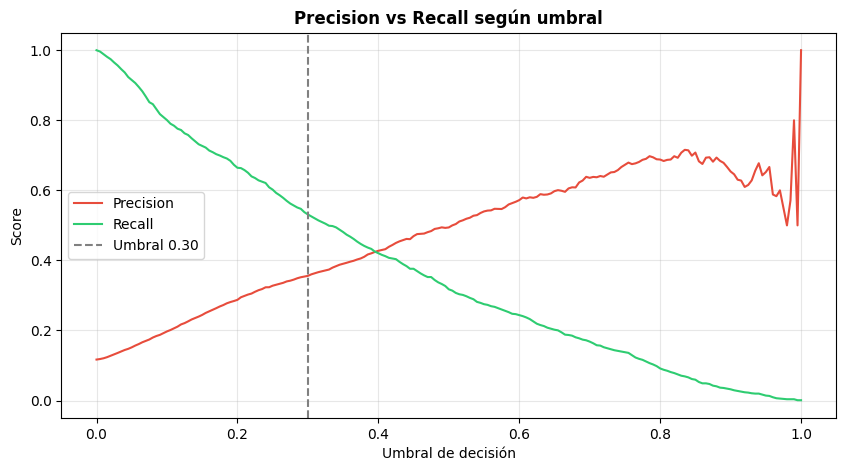

📊 Resultados con umbral = 0.3
              precision    recall  f1-score   support

 No suscribe       0.93      0.87      0.90      7985
    Suscribe       0.36      0.53      0.43      1058

    accuracy                           0.83      9043
   macro avg       0.64      0.70      0.66      9043
weighted avg       0.87      0.83      0.85      9043



In [24]:
from sklearn.metrics import precision_recall_curve

# Ver cómo cambian Precision y Recall según el umbral
y_proba = resultados_rf['y_proba']

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], color='#e74c3c', label='Precision')
plt.plot(thresholds, recalls[:-1], color='#2ecc71', label='Recall')
plt.axvline(x=0.3, color='gray', linestyle='--', label='Umbral 0.30')
plt.xlabel('Umbral de decisión')
plt.ylabel('Score')
plt.title('Precision vs Recall según umbral', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Probar umbral más bajo
umbral = 0.30
y_pred_ajustado = (y_proba >= umbral).astype(int)

print(f"📊 Resultados con umbral = {umbral}")
print("="*55)
print(classification_report(y_test, y_pred_ajustado,
                             target_names=['No suscribe', 'Suscribe']))

# Feature Importance

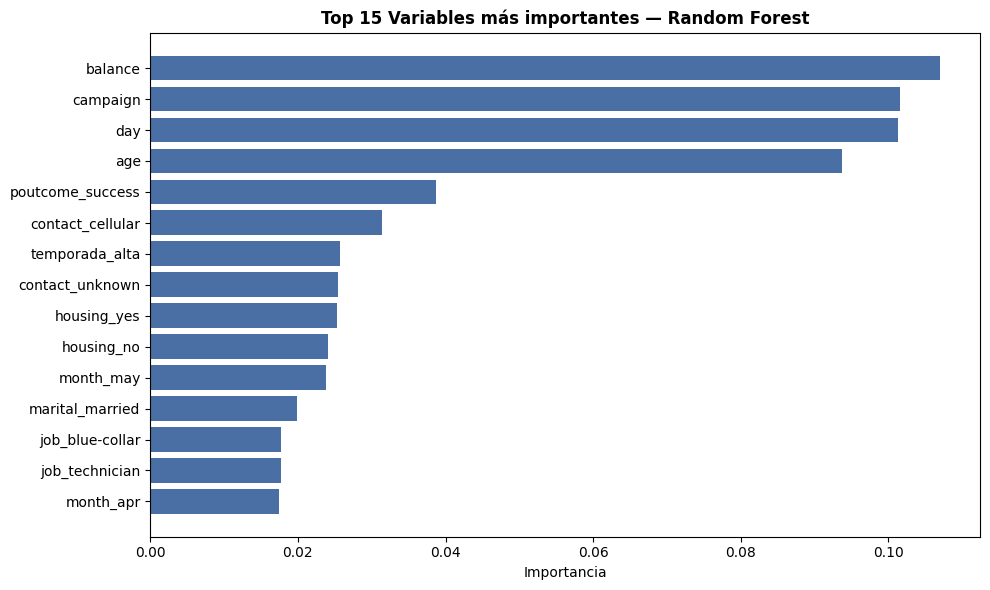


🔑 Top 5 variables predictoras:
  1. balance: 0.1071
  2. campaign: 0.1016
  3. day: 0.1014
  4. age: 0.0937
  5. poutcome_success: 0.0388


In [25]:
importances = pd.Series(
    rf_optimizado.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances.index[::-1],
         importances.values[::-1],
         color='#4A6FA5')
plt.xlabel('Importancia')
plt.title('Top 15 Variables más importantes — Random Forest',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔑 Top 5 variables predictoras:")
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

In [26]:

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_optimizado, "../models/random_forest.pkl")
print("✅ Modelo guardado en ../models/random_forest.pkl")

modelo_cargado = joblib.load("../models/random_forest.pkl")
print("✅ Modelo verificado correctamente")

✅ Modelo guardado en ../models/random_forest.pkl
✅ Modelo verificado correctamente


In [ ]:
print("""
CONCLUSIONES — Random Forest
══════════════════════════════════════════════════════
1. El modelo baseline ya tenía un AUC-ROC de 0.78,
   lo que indica buena capacidad de separación.

2. El GridSearch no mejoró significativamente porque
   los hiperparámetros óptimos en SMOTE no siempre
   generalizan igual en datos reales desbalanceados.

3. El ajuste de umbral a 0.30 fue la mejora más
   efectiva: el Recall de "Suscribe" subió de 0.31
   a 0.53, recuperando 229 clientes potenciales extra.

4. Las variables más importantes confirman el EDA:
   balance, campaign y poutcome_success lideran
   la predicción.

5. Recomendación de negocio: usar umbral 0.30 para
   maximizar la captación de clientes en campaña,
   asumiendo el coste de más llamadas en falso.

Modelo guardado → models/random_forest.pkl
Siguiente paso → 05_modeling.ipynb: comparación
final con el resto de modelos del equipo.
══════════════════════════════════════════════════════
""")